# GlobalTech Corp × AcquiredCo — HR Integration EDA Report
**Purpose:** Exploratory analysis and visualisation of the unified golden employee dataset produced by the HR data integration pipeline.

Run `main.py` first to generate the golden dataset before executing this notebook.

In [1]:
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

ROOT = Path().resolve().parent
OUTPUT_DIR = ROOT / 'output'
GOLDEN_PATH = OUTPUT_DIR / 'golden_dataset.parquet'
VALIDATION_PATH = OUTPUT_DIR / 'reports' / 'validation_report.csv'

PALETTE = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

In [2]:
df = pd.read_parquet(GOLDEN_PATH)
print(f'Golden dataset: {len(df):,} records, {df.shape[1]} columns')
df.head()

Golden dataset: 9,140 records, 30 columns


,source_employee_id,first_name,last_name,email,department,job_title,hire_date,country,employment_type,employment_status,...,employee_id,base_salary_numeric,base_salary_annual,salary_usd_annual,department_canonical,hire_date_flag,enrollment_date_flag,source_systems,dedup_method,source_system
0,1,Michael,King,michael.king@globaltech.com,Manufacturing,Data Analyst,2016-09-21,Netherlands,Full-Time,Active,...,GT-000001,76645.0,1992770.0,2172119.30,Manufacturing,ok,unparseable,globaltech_hris,email_match,NaN
1,2,David,Phillips,david.phillips@globaltech.com,Strategy,Systems Administrator,2022-02-06,India,Contractor,Active,...,GT-000002,108215.0,1298580.0,1298580.00,Strategy,ok,unparseable,globaltech_hris,email_match,NaN
2,3,Kenneth,Martinez,kenneth.martinez@globaltech.com,Human Resources,Business Analyst,2021-06-10,United Kingdom,Contractor,Active,...,GT-000003,62711.0,752532.0,820259.88,Human Resources,ok,unparseable,globaltech_hris,email_match,NaN
3,4,Paul,Cooper,paul.cooper@globaltech.com,Human Resources,Marketing Specialist,2024-09-07,Hong Kong,Full-Time,Active,...,GT-000004,126742.0,126742.0,126742.00,Human Resources,ok,unparseable,globaltech_hris,email_match,NaN
4,5,Stephen,Parker,stephen.parker@globaltech.com,Marketing,Project Manager,2023-03-09,China,Part-Time,Active,...,GT-000005,84499.0,84499.0,107313.73,Marketing,ok,unparseable,globaltech_hris,single_source,globaltech_hris


In [3]:
validation_report = pd.read_csv(VALIDATION_PATH) if VALIDATION_PATH.exists() else pd.DataFrame()
validation_report

,check,description,total,passed,failed,pass_rate,status,severity
0,NOT_NULL_EMPLOYEE_ID,'employee_id' must not be null,9140,9140,0,1.0000,PASS,CRITICAL
1,NOT_NULL_FIRST_NAME,'first_name' must not be null,9140,9140,0,1.0000,PASS,CRITICAL
2,NOT_NULL_LAST_NAME,'last_name' must not be null,9140,9140,0,1.0000,PASS,CRITICAL
3,NOT_NULL_EMAIL,'email' must not be null,9140,9140,0,1.0000,PASS,CRITICAL
4,NOT_NULL_DEPARTMENT_CANONICAL,'department_canonical' must not be null,9140,9125,15,0.9984,PASS,CRITICAL
5,NOT_NULL_COUNTRY,'country' must not be null,9140,9136,4,0.9996,PASS,CRITICAL
6,UNIQUE_EMAIL,'email' must be unique,9140,9140,0,1.0000,PASS,CRITICAL
7,UNIQUE_EMPLOYEE_ID,'employee_id' must be unique,9140,9140,0,1.0000,PASS,CRITICAL
8,IN_SET_EMPLOYMENT_TYPE,"'employment_type' in ['Contractor', 'Full-Time...",9140,9140,0,1.0000,PASS,CRITICAL
9,IN_SET_SALARY_CURRENCY,"'salary_currency' in ['EUR', 'GBP', 'USD']",9140,9140,0,1.0000,PASS,WARNING


## Data Preview — Golden Dataset

In [4]:
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes.to_string()}")
print(f"\nMissing values per column:\n{df.isna().sum()[df.isna().sum() > 0].to_string()}")
df.head(10)

Shape: (9140, 30)

Column dtypes:
source_employee_id                 str
first_name                         str
last_name                          str
email                              str
department                         str
job_title                          str
hire_date               datetime64[us]
country                            str
employment_type                    str
employment_status                  str
manager_id                         str
base_salary                        str
salary_currency                    str
pay_frequency                      str
bonus_target_pct                   str
benefits_enrolled                 bool
plan_type                          str
coverage_level                     str
enrollment_date         datetime64[us]
company_origin                     str
employee_id                        str
base_salary_numeric            float64
base_salary_annual             float64
salary_usd_annual              float64
department_canonical          

,source_employee_id,first_name,last_name,email,department,job_title,hire_date,country,employment_type,employment_status,...,employee_id,base_salary_numeric,base_salary_annual,salary_usd_annual,department_canonical,hire_date_flag,enrollment_date_flag,source_systems,dedup_method,source_system
0,1,Michael,King,michael.king@globaltech.com,Manufacturing,Data Analyst,2016-09-21,Netherlands,Full-Time,Active,...,GT-000001,76645.0,1992770.0,2172119.30,Manufacturing,ok,unparseable,globaltech_hris,email_match,NaN
1,2,David,Phillips,david.phillips@globaltech.com,Strategy,Systems Administrator,2022-02-06,India,Contractor,Active,...,GT-000002,108215.0,1298580.0,1298580.00,Strategy,ok,unparseable,globaltech_hris,email_match,NaN
2,3,Kenneth,Martinez,kenneth.martinez@globaltech.com,Human Resources,Business Analyst,2021-06-10,United Kingdom,Contractor,Active,...,GT-000003,62711.0,752532.0,820259.88,Human Resources,ok,unparseable,globaltech_hris,email_match,NaN
3,4,Paul,Cooper,paul.cooper@globaltech.com,Human Resources,Marketing Specialist,2024-09-07,Hong Kong,Full-Time,Active,...,GT-000004,126742.0,126742.0,126742.00,Human Resources,ok,unparseable,globaltech_hris,email_match,NaN
4,5,Stephen,Parker,stephen.parker@globaltech.com,Marketing,Project Manager,2023-03-09,China,Part-Time,Active,...,GT-000005,84499.0,84499.0,107313.73,Marketing,ok,unparseable,globaltech_hris,single_source,globaltech_hris
5,6,Patricia,Morris,patricia.morris@globaltech.com,Data Science,Systems Administrator,2018-12-31,Germany,Part-Time,Active,...,GT-000006,123573.0,3212898.0,3212898.00,Data Science,ok,unparseable,globaltech_hris,email_match,NaN
6,7,Andrew,Bennett,andrew.bennett@globaltech.com,Product,Data Engineer,2015-01-08,Switzerland,Full-Time,Active,...,GT-000007,72847.0,1894022.0,2064483.98,Product,ok,unparseable,globaltech_hris,email_match,NaN
7,8,Linda,Thomas,linda.thomas@globaltech.com,Manufacturing,Financial Analyst,2021-02-08,Japan,Full-Time,Active,...,GT-000008,53593.0,1393418.0,1769640.86,Manufacturing,ok,unparseable,globaltech_hris,email_match,NaN
8,9,Scott,Kennedy,scott.kennedy@globaltech.com,Human Resources,Data Engineer,2015-06-05,Canada,Full-Time,Active,...,GT-000009,86955.0,2260830.0,2464304.70,Human Resources,ok,unparseable,globaltech_hris,email_match,NaN
9,10,Thomas,Martin,thomas.martin@globaltech.com,Manufacturing,Account Executive,2022-10-17,Germany,Contractor,Active,...,GT-000010,72110.0,72110.0,72110.00,Manufacturing,ok,unparseable,globaltech_hris,single_source,globaltech_hris


## Data Quality Validation Results

In [5]:
if validation_report.empty:
    print("Run main.py first to generate the validation report.")
else:
    def _highlight_status(row):
        bg = {"PASS": "background-color: #d4edda", "WARN": "background-color: #fff3cd",
              "FAIL": "background-color: #f8d7da"}.get(row["status"], "")
        return [bg] * len(row)

    display(
        validation_report.style
        .apply(_highlight_status, axis=1)
        .format({"pass_rate": "{:.1%}", "total": "{:,}", "passed": "{:,}", "failed": "{:,}"})
        .set_caption("HR Data Quality Validation Report")
        .hide(axis="index")
    )
    total_checks = len(validation_report)
    passed_checks = (validation_report["status"] == "PASS").sum()
    print(f"\nSummary: {passed_checks}/{total_checks} checks passed")

check,description,total,passed,failed,pass_rate,status,severity
NOT_NULL_EMPLOYEE_ID,'employee_id' must not be null,"9,140","9,140",0,100.0%,PASS,CRITICAL
NOT_NULL_FIRST_NAME,'first_name' must not be null,"9,140","9,140",0,100.0%,PASS,CRITICAL
NOT_NULL_LAST_NAME,'last_name' must not be null,"9,140","9,140",0,100.0%,PASS,CRITICAL
NOT_NULL_EMAIL,'email' must not be null,"9,140","9,140",0,100.0%,PASS,CRITICAL
NOT_NULL_DEPARTMENT_CANONICAL,'department_canonical' must not be null,"9,140","9,125",15,99.8%,PASS,CRITICAL
NOT_NULL_COUNTRY,'country' must not be null,"9,140","9,136",4,100.0%,PASS,CRITICAL
UNIQUE_EMAIL,'email' must be unique,"9,140","9,140",0,100.0%,PASS,CRITICAL
UNIQUE_EMPLOYEE_ID,'employee_id' must be unique,"9,140","9,140",0,100.0%,PASS,CRITICAL
IN_SET_EMPLOYMENT_TYPE,"'employment_type' in ['Contractor', 'Full-Time', 'Part-Time']","9,140","9,140",0,100.0%,PASS,CRITICAL
IN_SET_SALARY_CURRENCY,"'salary_currency' in ['EUR', 'GBP', 'USD']","9,140","9,140",0,100.0%,PASS,WARNING



Summary: 13/15 checks passed


## Chart 1 — Headcount by Department

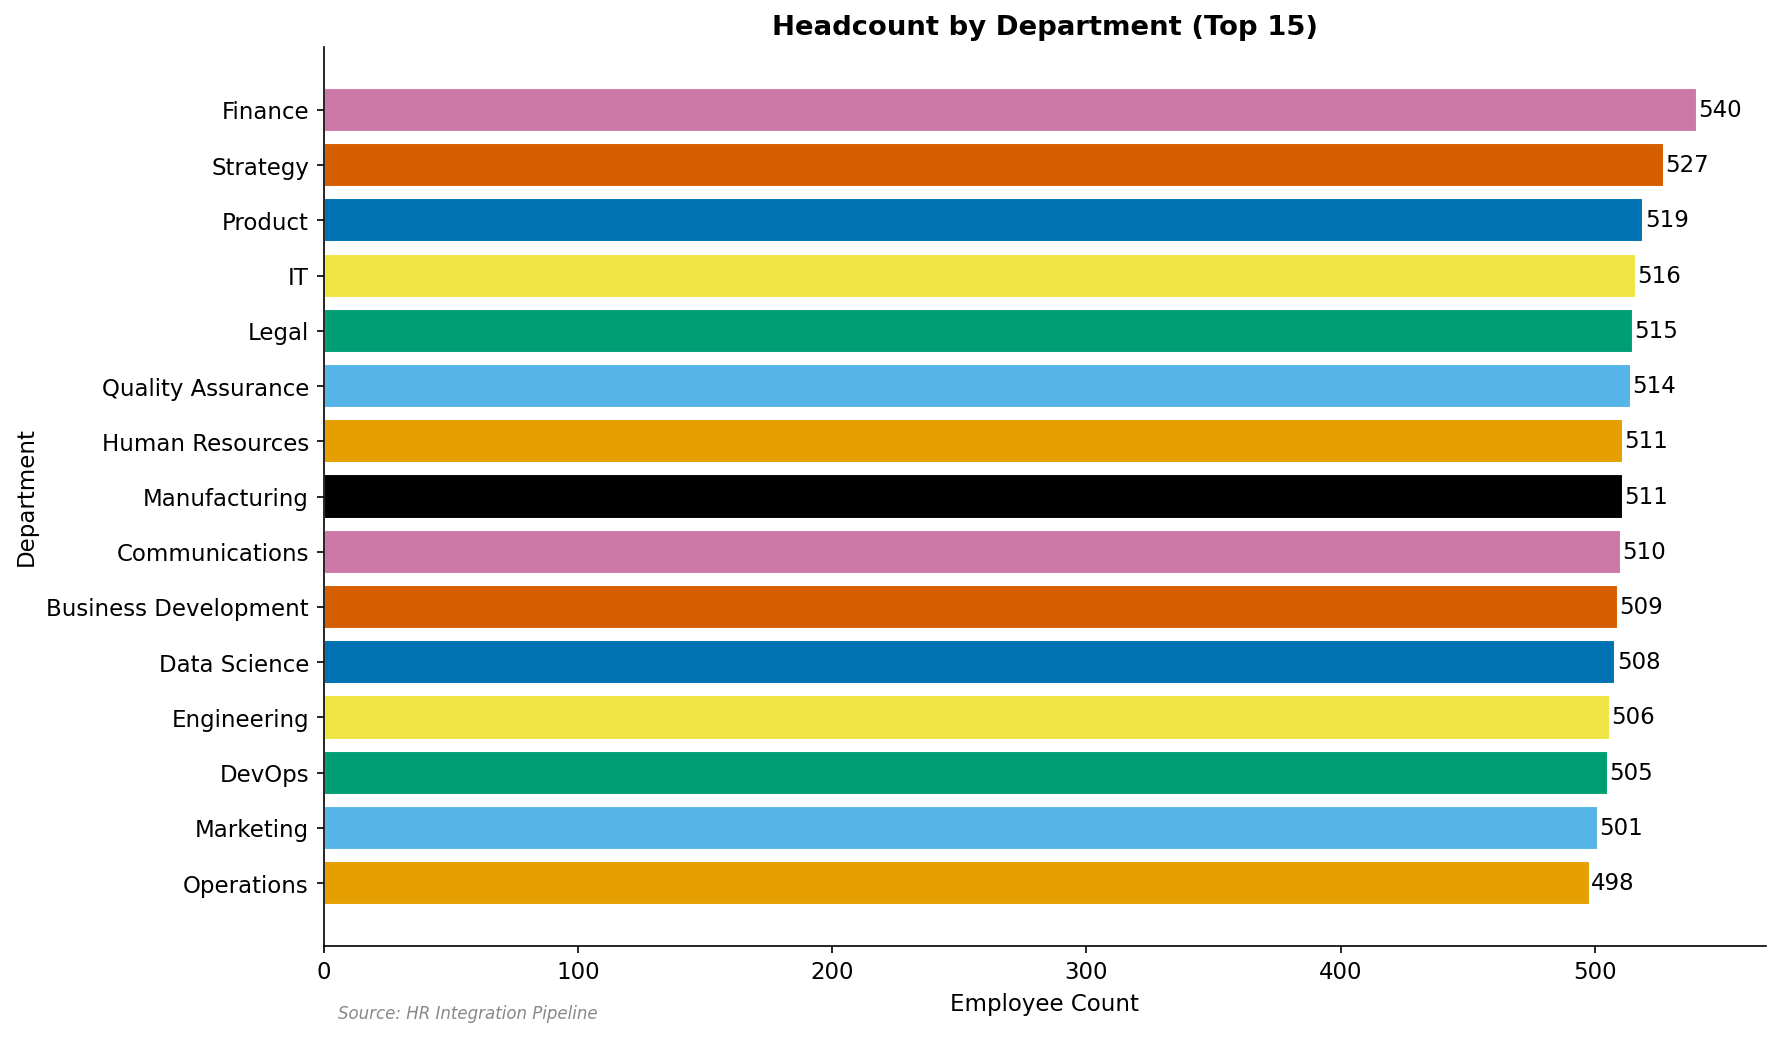

In [6]:
dept_col = 'department_canonical' if 'department_canonical' in df.columns else 'department'
counts = df[dept_col].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
colours = [PALETTE[i % len(PALETTE)] for i in range(len(counts))]
bars = ax.barh(counts.index, counts.values, color=colours, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center')
ax.set_xlabel('Employee Count')
ax.set_ylabel('Department')
ax.set_title('Headcount by Department (Top 15)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.annotate('Source: HR Integration Pipeline', xy=(0.01, -0.08), xycoords='axes fraction', fontsize=8, color='#888', style='italic')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart1_headcount_by_dept.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 2 — Headcount by Country

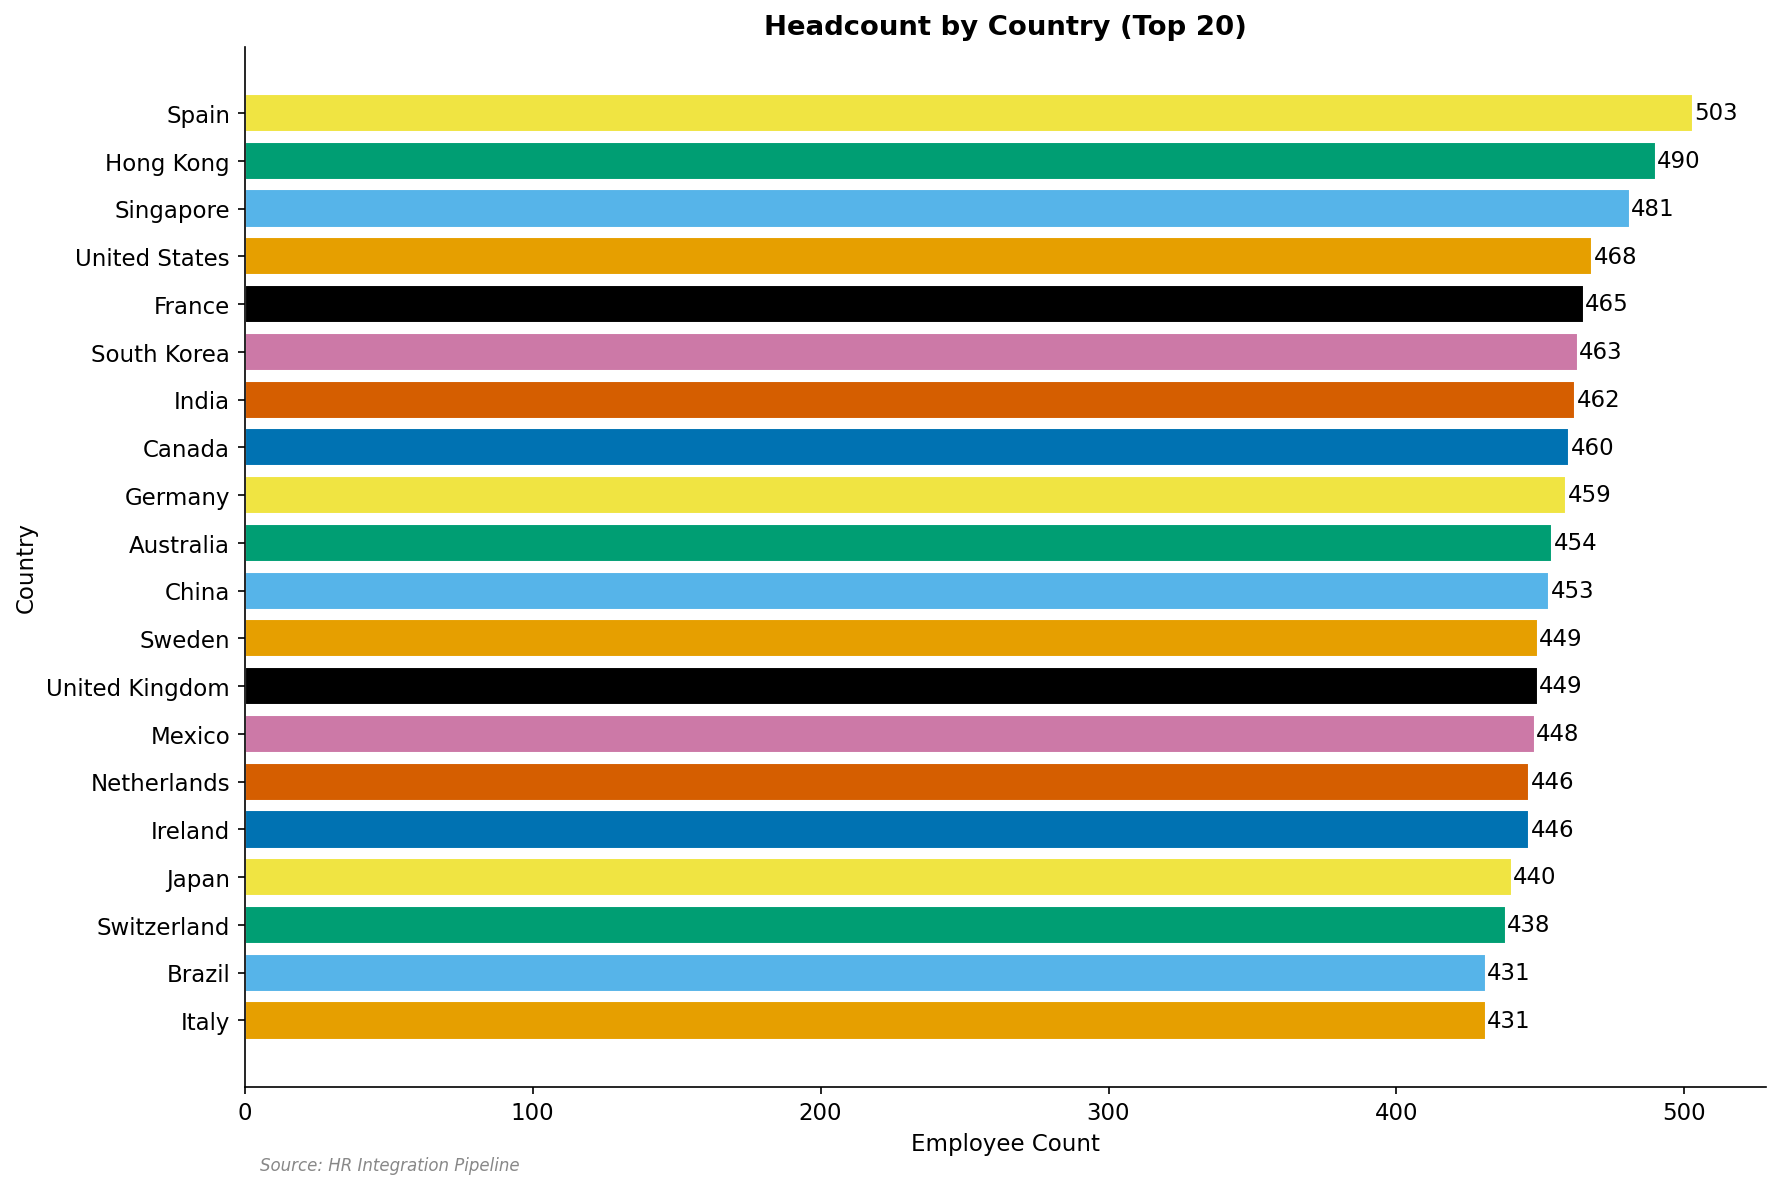

In [7]:
counts = df['country'].value_counts().head(20).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colours = [PALETTE[i % len(PALETTE)] for i in range(len(counts))]
bars = ax.barh(counts.index, counts.values, color=colours, edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center')
ax.set_xlabel('Employee Count')
ax.set_ylabel('Country')
ax.set_title('Headcount by Country (Top 20)', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.annotate('Source: HR Integration Pipeline', xy=(0.01, -0.08), xycoords='axes fraction', fontsize=8, color='#888', style='italic')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart2_headcount_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 3 — Salary Distribution by Employment Type

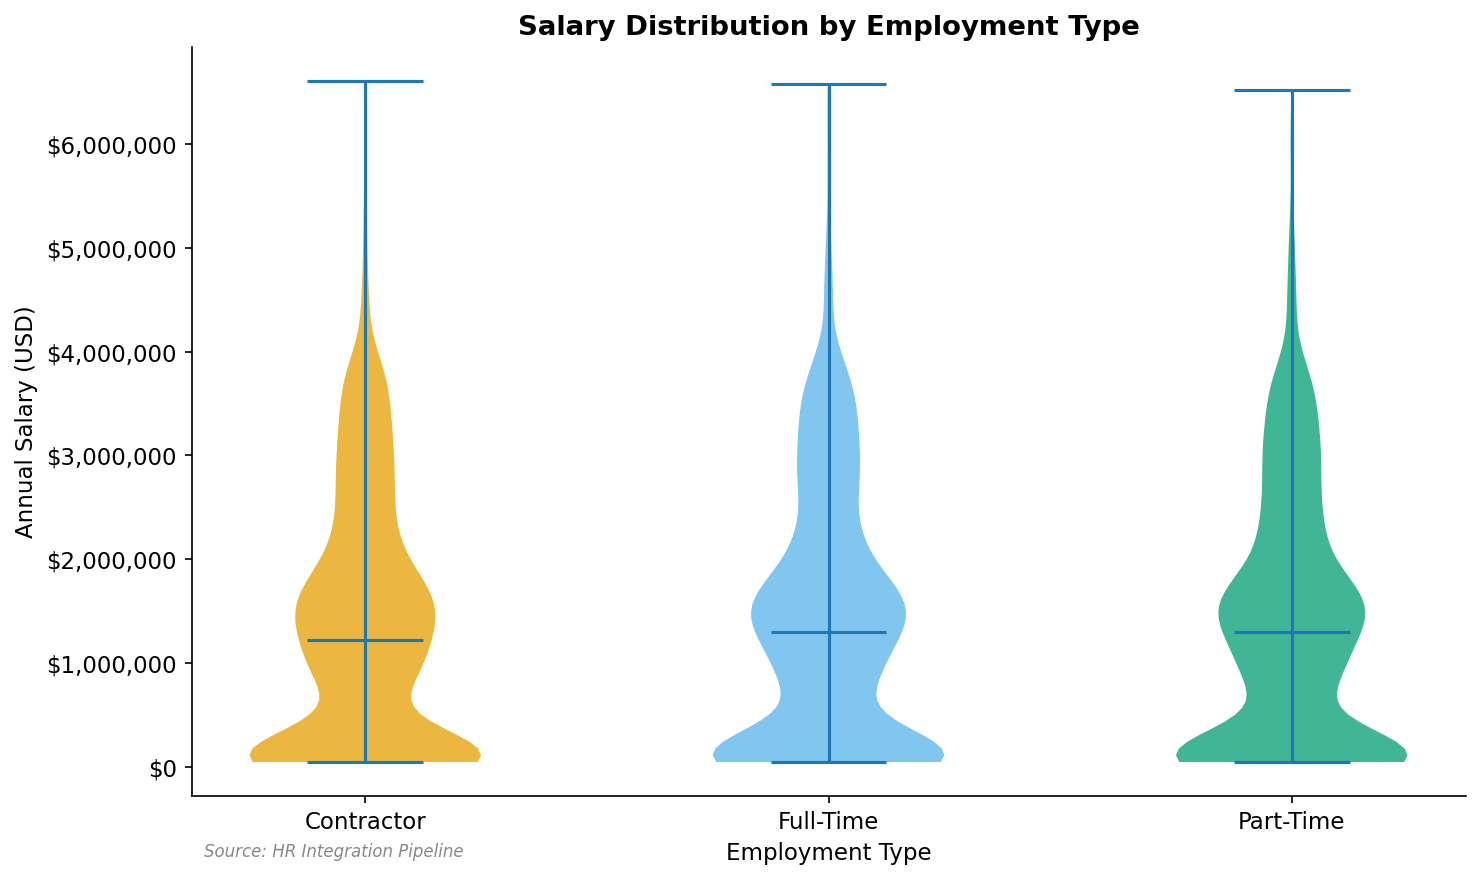

In [8]:
plot_df = df[['employment_type', 'salary_usd_annual']].dropna()
types = sorted(plot_df['employment_type'].dropna().unique())
data = [plot_df.loc[plot_df['employment_type'] == t, 'salary_usd_annual'].values for t in types]

fig, ax = plt.subplots(figsize=(10, 6))
parts = ax.violinplot(data, positions=range(len(types)), showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i % len(PALETTE)])
    pc.set_alpha(0.75)
ax.set_xticks(range(len(types)))
ax.set_xticklabels(types)
ax.set_ylabel('Annual Salary (USD)')
ax.set_xlabel('Employment Type')
ax.set_title('Salary Distribution by Employment Type', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
ax.annotate('Source: HR Integration Pipeline', xy=(0.01, -0.08), xycoords='axes fraction', fontsize=8, color='#888', style='italic')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart3_salary_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 4 — Tenure Distribution

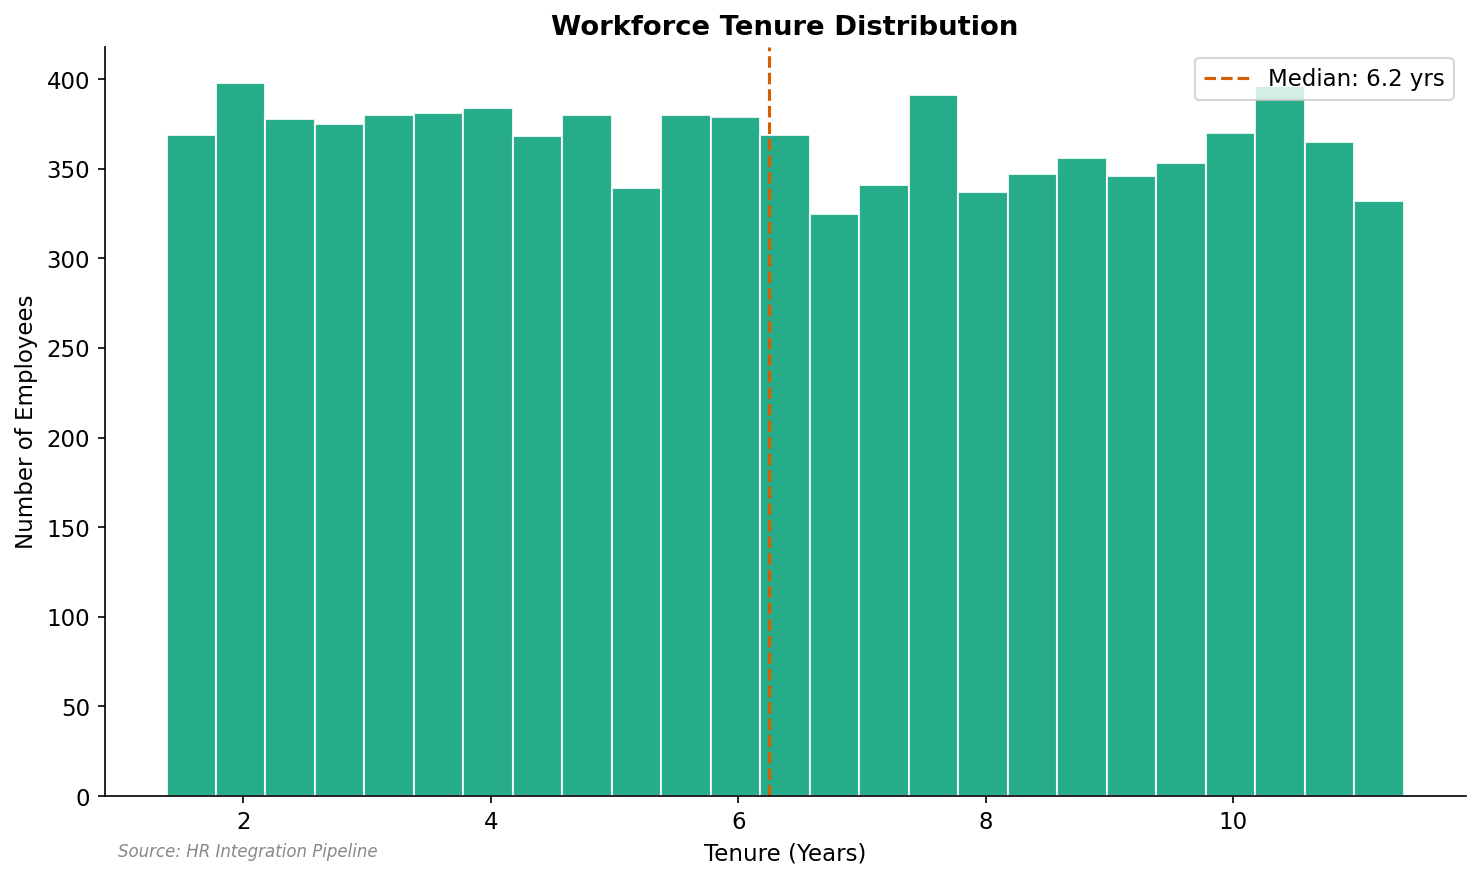

In [9]:
today = pd.Timestamp.today()
tenure = ((today - pd.to_datetime(df['hire_date'], errors='coerce')).dt.days / 365.25).dropna().clip(lower=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(tenure, bins=25, color=PALETTE[2], edgecolor='white', alpha=0.85)
median = tenure.median()
ax.axvline(median, color=PALETTE[5], linestyle='--', linewidth=1.5, label=f'Median: {median:.1f} yrs')
ax.legend()
ax.set_xlabel('Tenure (Years)')
ax.set_ylabel('Number of Employees')
ax.set_title('Workforce Tenure Distribution', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.annotate('Source: HR Integration Pipeline', xy=(0.01, -0.08), xycoords='axes fraction', fontsize=8, color='#888', style='italic')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart4_tenure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 5 — Benefits Enrollment Rate by Department

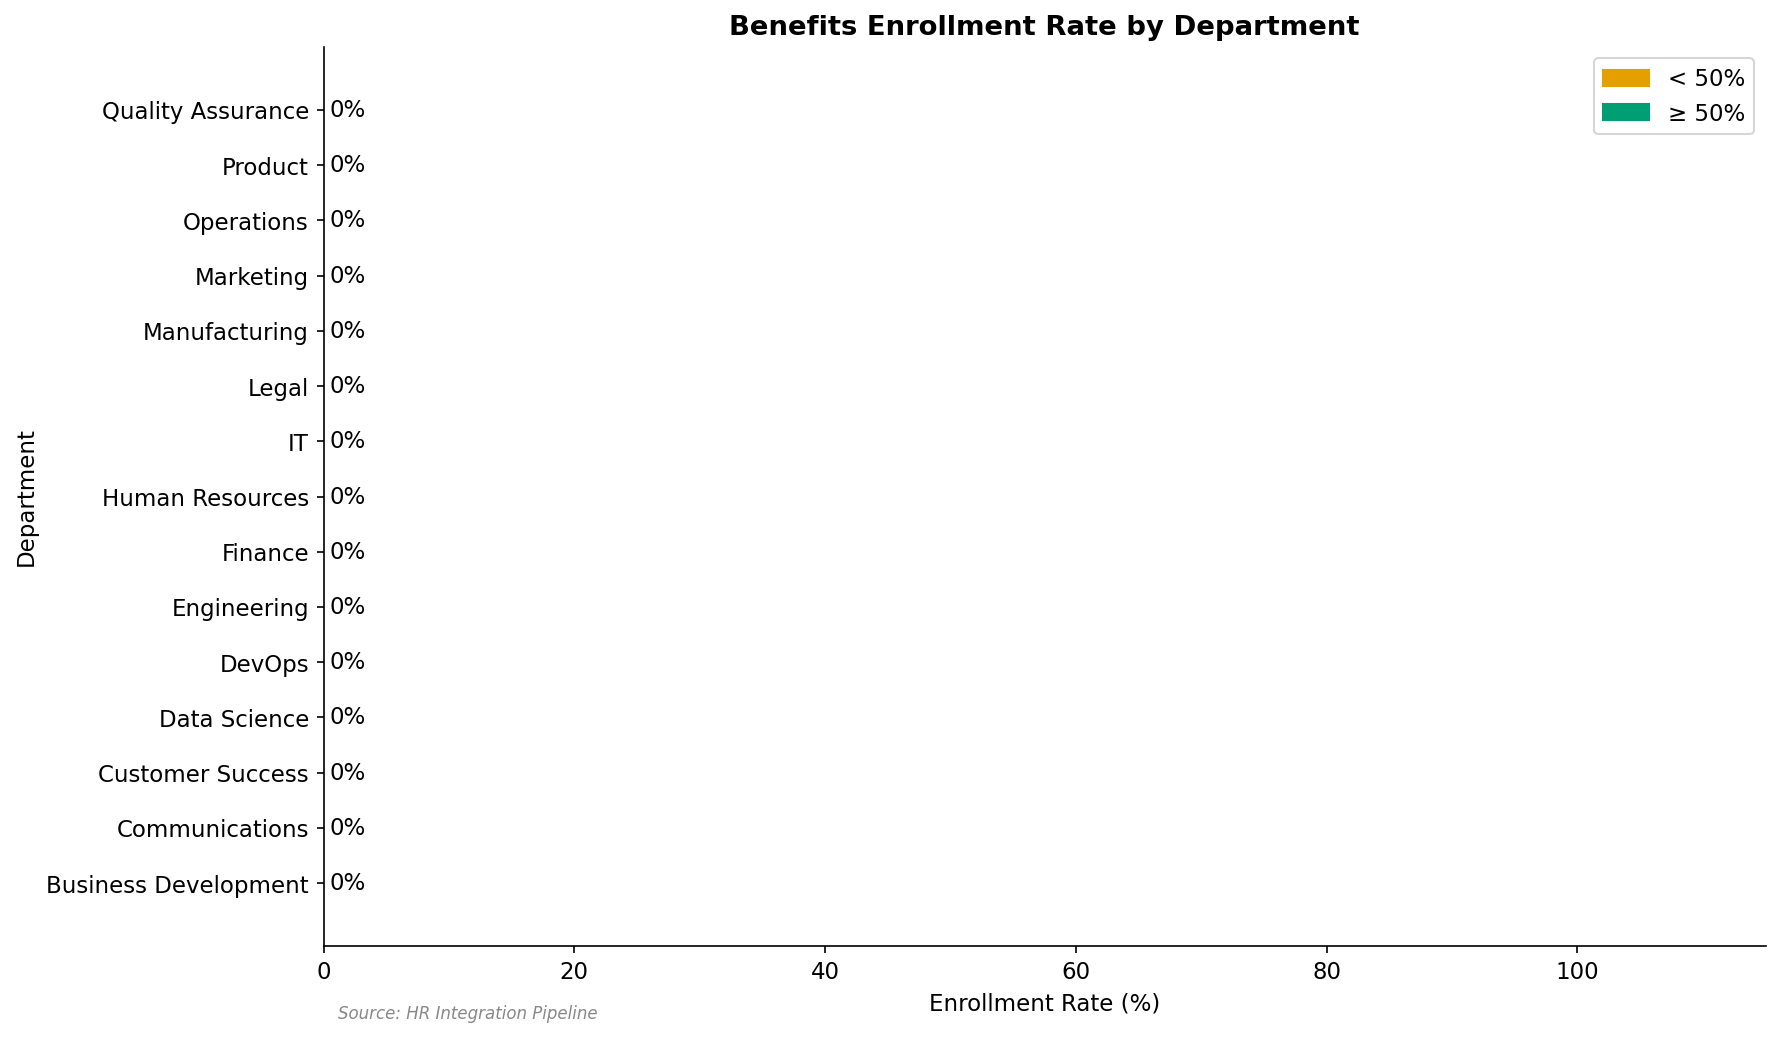

In [10]:
dept_col = 'department_canonical' if 'department_canonical' in df.columns else 'department'
plot_df = df[[dept_col, 'benefits_enrolled']].dropna(subset=[dept_col]).copy()
plot_df['benefits_enrolled'] = plot_df['benefits_enrolled'].astype(bool)
rate = plot_df.groupby(dept_col)['benefits_enrolled'].mean().sort_values().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colours = [PALETTE[0] if r < 0.5 else PALETTE[2] for r in rate.values]
bars = ax.barh(rate.index, rate.values * 100, color=colours, edgecolor='white')
for bar, val in zip(bars, rate.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.0%}', va='center')
ax.set_xlim(0, 115)
ax.set_xlabel('Enrollment Rate (%)')
ax.set_ylabel('Department')
ax.set_title('Benefits Enrollment Rate by Department', fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color=PALETTE[0], label='< 50%'),
    mpatches.Patch(color=PALETTE[2], label='≥ 50%'),
])
ax.spines[['top', 'right']].set_visible(False)
ax.annotate('Source: HR Integration Pipeline', xy=(0.01, -0.08), xycoords='axes fraction', fontsize=8, color='#888', style='italic')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart5_benefits_enrollment.png', dpi=300, bbox_inches='tight')
plt.show()

## Chart 6 — Data Quality Summary (Pipeline Health Dashboard)

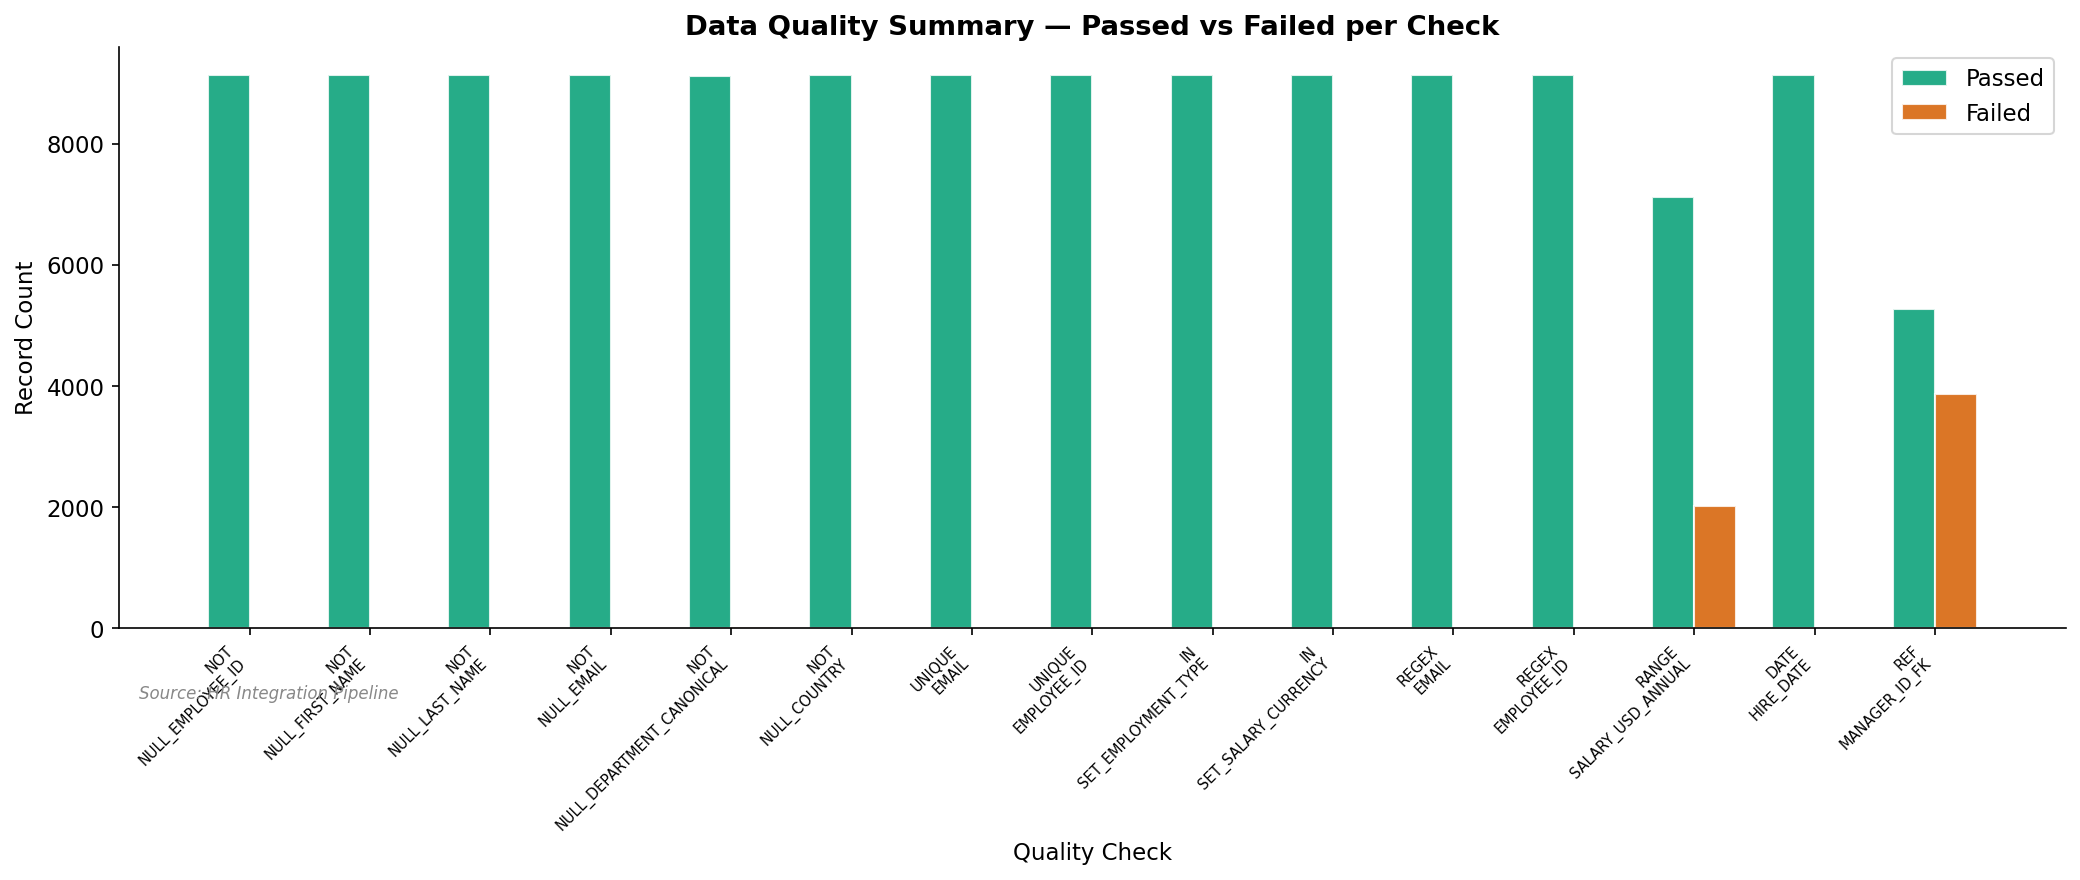

In [11]:
if validation_report.empty:
    print('No validation report found. Run main.py first.')
else:
    x = np.arange(len(validation_report))
    w = 0.35
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(x - w / 2, validation_report['passed'], w, label='Passed', color=PALETTE[2], alpha=0.85, edgecolor='white')
    ax.bar(x + w / 2, validation_report['failed'], w, label='Failed',  color=PALETTE[5], alpha=0.85, edgecolor='white')
    labels = [c.replace('_', '\n', 1) for c in validation_report['check']]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
    ax.set_ylabel('Record Count')
    ax.set_xlabel('Quality Check')
    ax.set_title('Data Quality Summary — Passed vs Failed per Check', fontweight='bold')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    ax.annotate('Source: HR Integration Pipeline', xy=(0.01, -0.12), xycoords='axes fraction', fontsize=8, color='#888', style='italic')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'chart6_data_quality.png', dpi=300, bbox_inches='tight')
    plt.show()

## Combined Multi-Panel Report (300 DPI PNG)

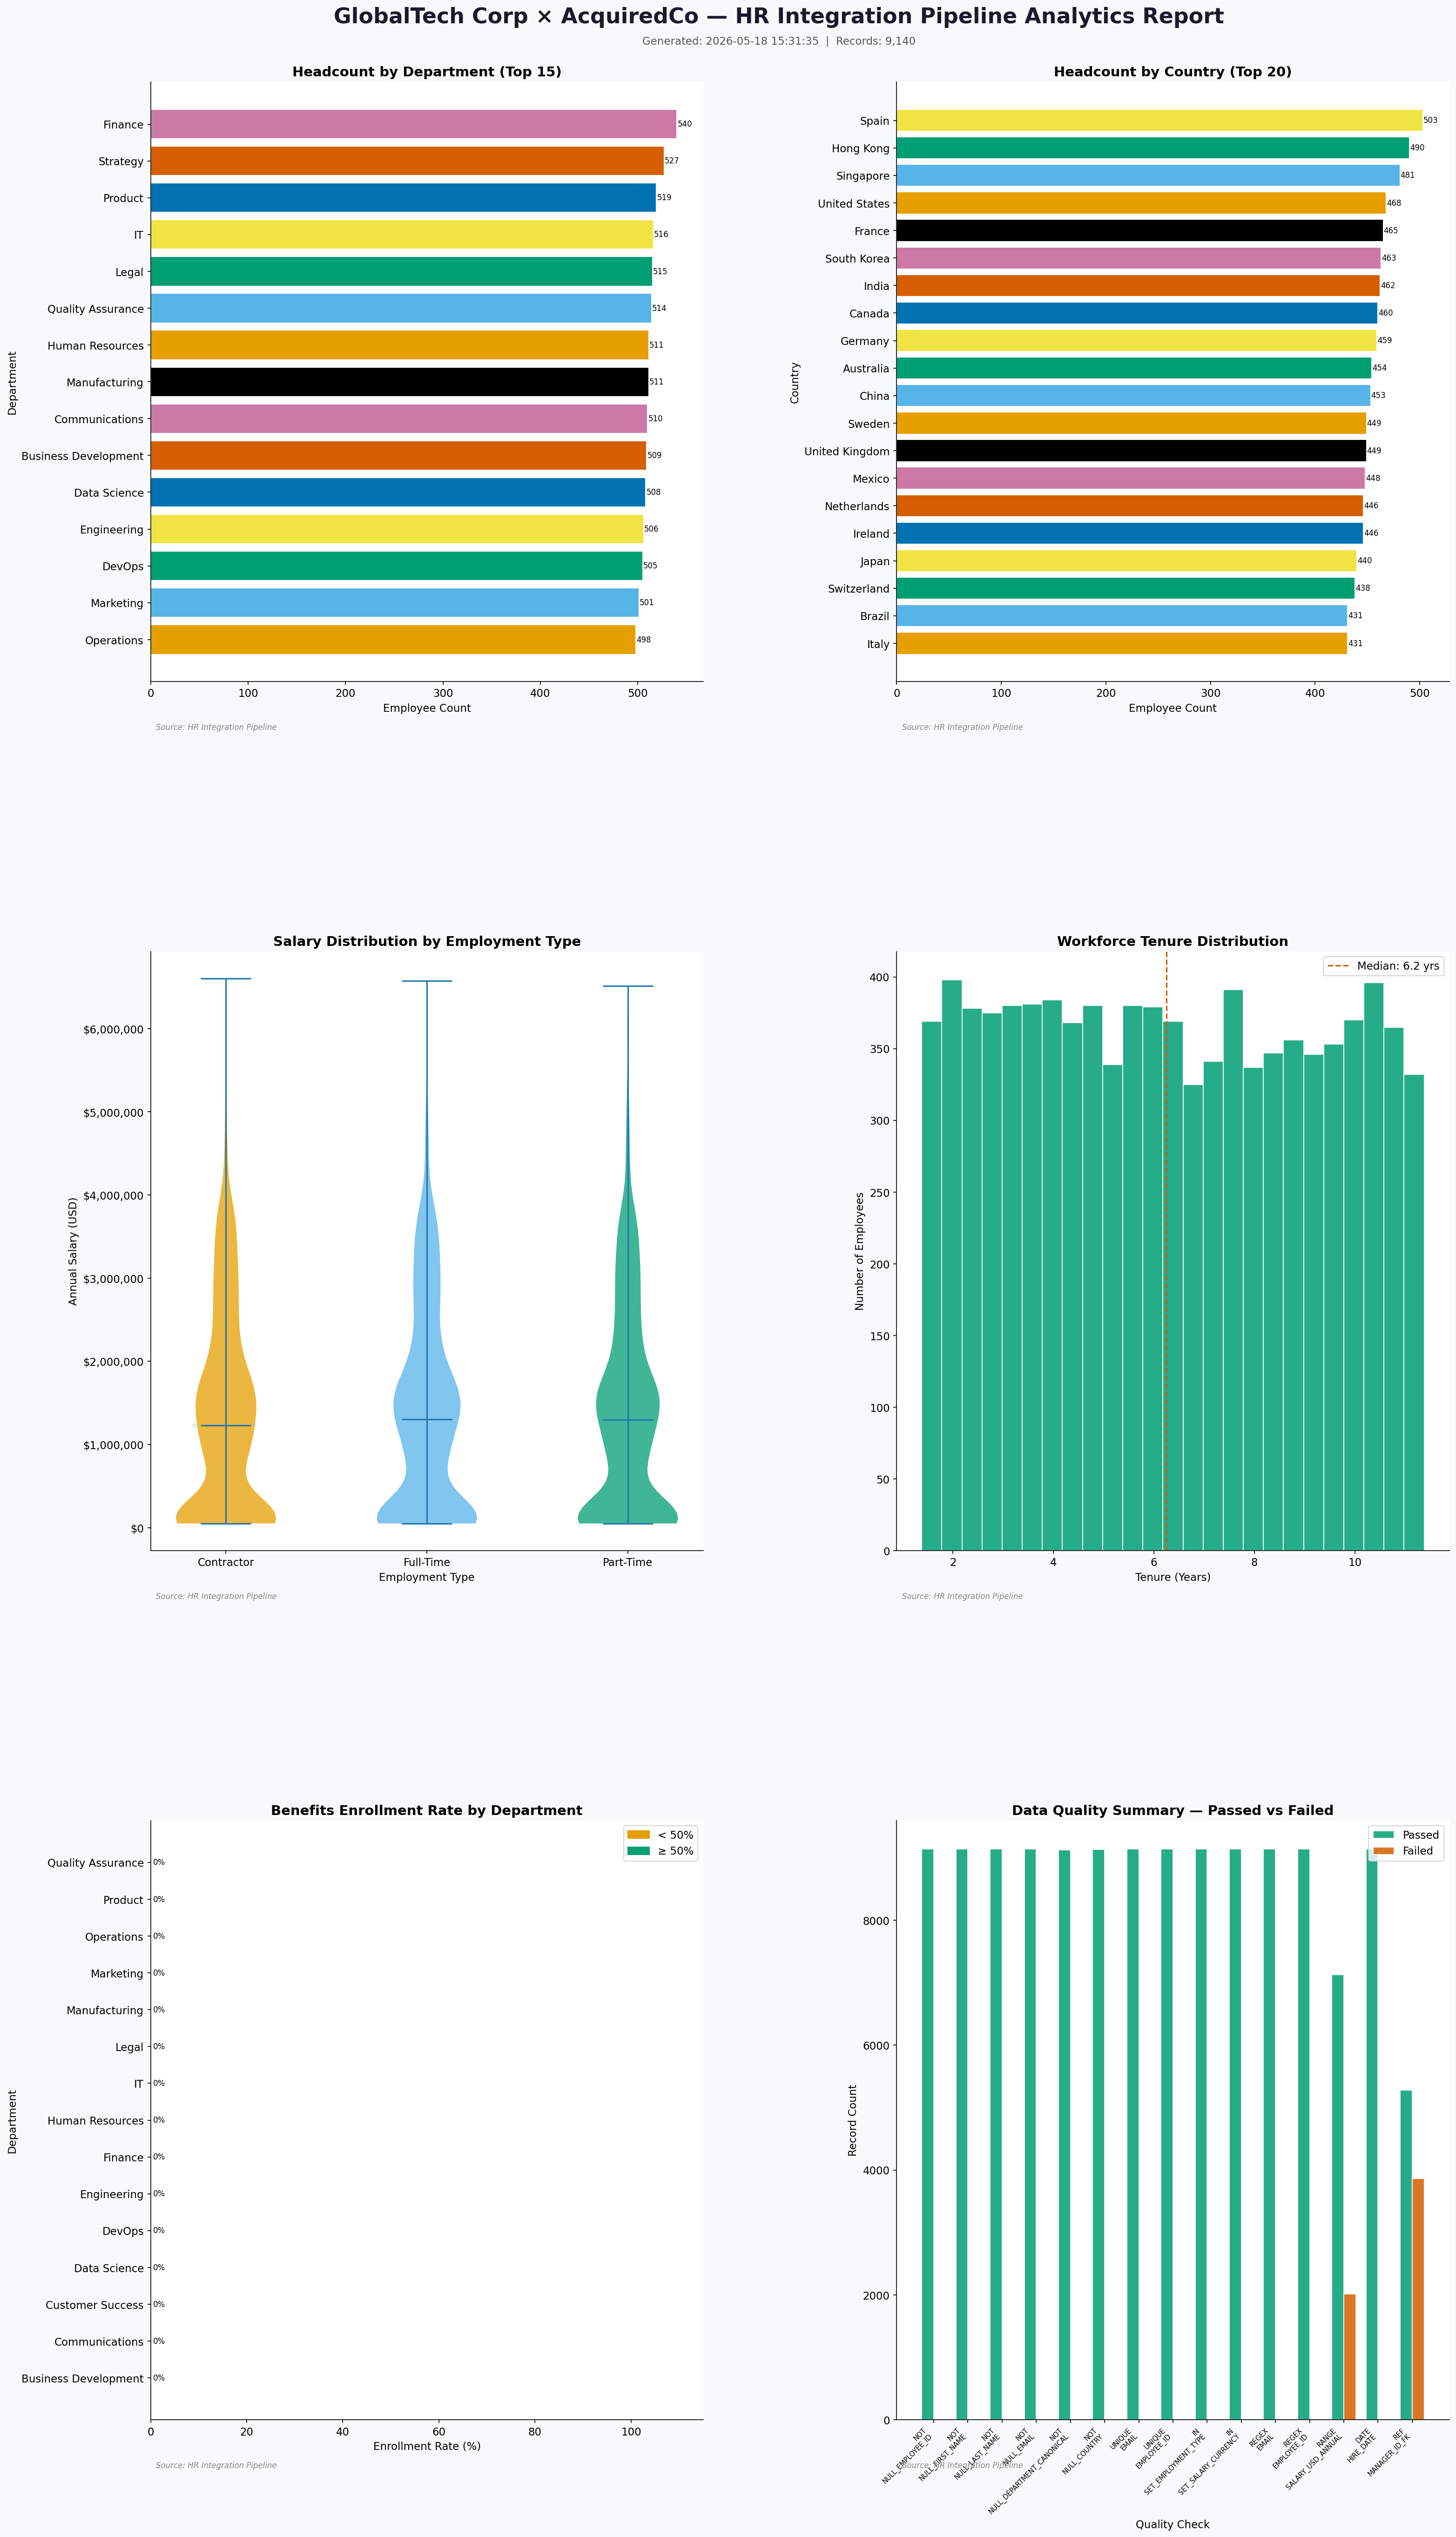


Full report saved to C:\Users\PatrickIradukunda\Desktop\Patrick-de-t-shaped-program-project-repo\sk-01-project\output\eda_report.png (300 DPI)


In [12]:
from datetime import datetime

fig = plt.figure(figsize=(24, 36), facecolor='#f8f9fa')
fig.suptitle(
    'GlobalTech Corp × AcquiredCo — HR Integration Pipeline Analytics Report',
    fontsize=22, fontweight='bold', y=0.99, color='#1a1a2e',
)
fig.text(
    0.5, 0.975,
    f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  |  Records: {len(df):,}",
    ha='center', fontsize=11, color='#555',
)

def annotate(ax):
    ax.annotate('Source: HR Integration Pipeline', xy=(0.01, -0.08), xycoords='axes fraction', fontsize=8, color='#888', style='italic')

gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35, top=0.96, bottom=0.03)

# Chart 1
ax1 = fig.add_subplot(gs[0, 0])
dept_col = 'department_canonical' if 'department_canonical' in df.columns else 'department'
counts = df[dept_col].value_counts().head(15).sort_values()
bars = ax1.barh(counts.index, counts.values, color=[PALETTE[i % len(PALETTE)] for i in range(len(counts))], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontsize=8)
ax1.set_xlabel('Employee Count'); ax1.set_ylabel('Department')
ax1.set_title('Headcount by Department (Top 15)', fontsize=14, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False); annotate(ax1)

# Chart 2
ax2 = fig.add_subplot(gs[0, 1])
counts2 = df['country'].value_counts().head(20).sort_values()
bars2 = ax2.barh(counts2.index, counts2.values, color=[PALETTE[i % len(PALETTE)] for i in range(len(counts2))], edgecolor='white')
for bar, val in zip(bars2, counts2.values):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va='center', fontsize=8)
ax2.set_xlabel('Employee Count'); ax2.set_ylabel('Country')
ax2.set_title('Headcount by Country (Top 20)', fontsize=14, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False); annotate(ax2)

# Chart 3
ax3 = fig.add_subplot(gs[1, 0])
plot_df3 = df[['employment_type', 'salary_usd_annual']].dropna()
types3 = sorted(plot_df3['employment_type'].dropna().unique())
data3 = [plot_df3.loc[plot_df3['employment_type'] == t, 'salary_usd_annual'].values for t in types3]
if data3 and all(len(d) > 0 for d in data3):
    parts3 = ax3.violinplot(data3, positions=range(len(types3)), showmedians=True)
    for i, pc in enumerate(parts3['bodies']): pc.set_facecolor(PALETTE[i % len(PALETTE)]); pc.set_alpha(0.75)
ax3.set_xticks(range(len(types3))); ax3.set_xticklabels(types3)
ax3.set_ylabel('Annual Salary (USD)'); ax3.set_xlabel('Employment Type')
ax3.set_title('Salary Distribution by Employment Type', fontsize=14, fontweight='bold')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax3.spines[['top', 'right']].set_visible(False); annotate(ax3)

# Chart 4
ax4 = fig.add_subplot(gs[1, 1])
tenure = ((pd.Timestamp.today() - pd.to_datetime(df['hire_date'], errors='coerce')).dt.days / 365.25).dropna().clip(lower=0)
ax4.hist(tenure, bins=25, color=PALETTE[2], edgecolor='white', alpha=0.85)
median = tenure.median()
ax4.axvline(median, color=PALETTE[5], linestyle='--', linewidth=1.5, label=f'Median: {median:.1f} yrs')
ax4.legend(); ax4.set_xlabel('Tenure (Years)'); ax4.set_ylabel('Number of Employees')
ax4.set_title('Workforce Tenure Distribution', fontsize=14, fontweight='bold')
ax4.spines[['top', 'right']].set_visible(False); annotate(ax4)

# Chart 5
ax5 = fig.add_subplot(gs[2, 0])
plot_df5 = df[[dept_col, 'benefits_enrolled']].dropna(subset=[dept_col]).copy()
plot_df5['benefits_enrolled'] = plot_df5['benefits_enrolled'].astype(bool)
rate5 = plot_df5.groupby(dept_col)['benefits_enrolled'].mean().sort_values().head(15)
bars5 = ax5.barh(rate5.index, rate5.values * 100, color=[PALETTE[0] if r < 0.5 else PALETTE[2] for r in rate5.values], edgecolor='white')
for bar, val in zip(bars5, rate5.values):
    ax5.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.0%}', va='center', fontsize=8)
ax5.set_xlim(0, 115); ax5.set_xlabel('Enrollment Rate (%)'); ax5.set_ylabel('Department')
ax5.set_title('Benefits Enrollment Rate by Department', fontsize=14, fontweight='bold')
ax5.legend(handles=[mpatches.Patch(color=PALETTE[0], label='< 50%'), mpatches.Patch(color=PALETTE[2], label='≥ 50%')])
ax5.spines[['top', 'right']].set_visible(False); annotate(ax5)

# Chart 6
ax6 = fig.add_subplot(gs[2, 1])
if not validation_report.empty:
    x = np.arange(len(validation_report)); w = 0.35
    ax6.bar(x - w/2, validation_report['passed'], w, label='Passed', color=PALETTE[2], alpha=0.85, edgecolor='white')
    ax6.bar(x + w/2, validation_report['failed'],  w, label='Failed',  color=PALETTE[5], alpha=0.85, edgecolor='white')
    ax6.set_xticks(x)
    ax6.set_xticklabels([c.replace('_', '\n', 1) for c in validation_report['check']], fontsize=7, rotation=45, ha='right')
    ax6.set_ylabel('Record Count'); ax6.set_xlabel('Quality Check')
    ax6.set_title('Data Quality Summary — Passed vs Failed', fontsize=14, fontweight='bold')
    ax6.legend(); ax6.spines[['top', 'right']].set_visible(False); annotate(ax6)
else:
    ax6.text(0.5, 0.5, 'No validation data available', ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('Data Quality Summary', fontsize=14, fontweight='bold')

out_path = OUTPUT_DIR / 'eda_report.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'\nFull report saved to {out_path} (300 DPI)')